# Book Recommendation System 📖

### Business Objective

### Objective: 
Build a Book Recommendation System that recommends books to users using traditional Machine Learning and Deep Learning recommendation techniques.

#### STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 #### STEP 2: LOAD DATASETS

In [2]:
import pandas as pd

users = pd.read_csv("Users.csv", encoding="latin-1")
books = pd.read_csv("Books.csv", encoding="latin-1")
ratings = pd.read_csv("Ratings.csv", encoding="latin-1")

ratings = ratings.sample(n=25000, random_state=42)



C:\Users\SATYA GOWRI\AppData\Local\Temp\ipykernel_62088\912913332.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("Books.csv", encoding="latin-1")


#### STEP 3: DATA UNDERSTANDING

In [3]:
# Dataset Shape
print(users.shape)
print(books.shape)
print(ratings.shape)

# Dataset Information
users.info()
books.info()
ratings.info()

# Statistical Summary
users.describe()
ratings.describe()

(278858, 3)
(271360, 8)
(25000, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 

,User-ID,Book-Rating
count,25000.000000,25000.000000
mean,139833.061720,2.865400
std,80522.678856,3.852183
min,8.000000,0.000000
25%,69697.000000,0.000000
50%,140061.500000,0.000000
75%,210385.500000,7.000000
max,278852.000000,10.000000


 #### STEP 4: DATA PREPROCESSING

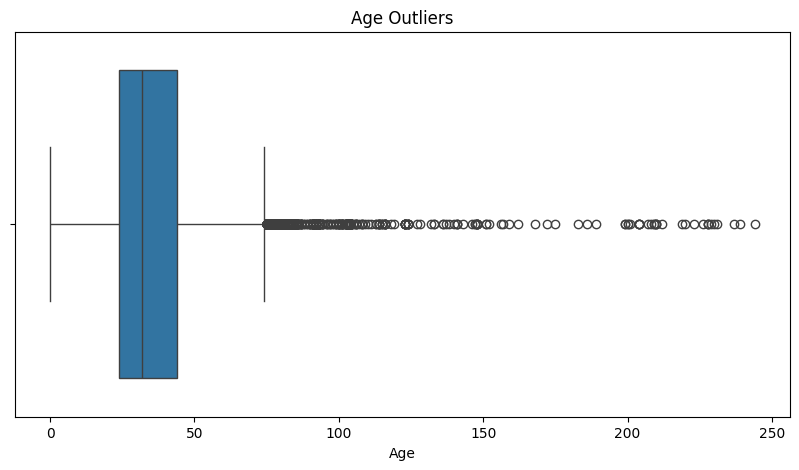

In [4]:
# Missing Value Analysis
books.isnull().sum()
ratings.isnull().sum()

# Duplicate Value Analysis
users.duplicated().sum()
books.duplicated().sum()
ratings.duplicated().sum()

# Outlier Detection
plt.figure(figsize=(10,5))
sns.boxplot(x=users['Age'])
plt.title("Age Outliers")
plt.show()

#### STEP 5: EXPLORATORY DATA ANALYSIS(EDA)

In [5]:
# Handling Missing Values
users['Age'] = users['Age'].fillna(
users['Age'].median()
)

# Outlier Treatment
users = users[
(users['Age'] >= 5) &
(users['Age'] <= 100)
]

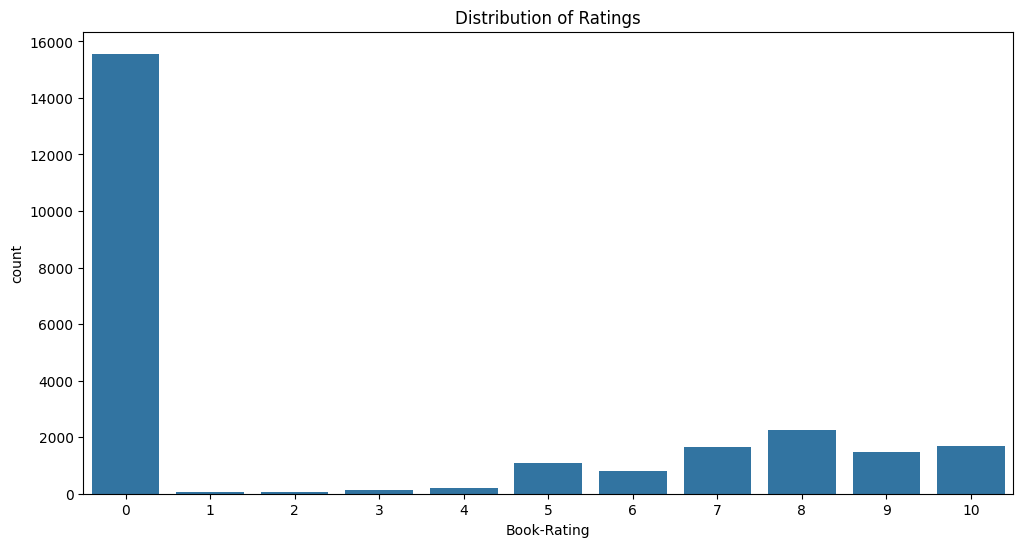

In [6]:
# Rating Distribution Analysis
plt.figure(figsize=(12,6))
sns.countplot(
x='Book-Rating',
data=ratings
)
plt.title("Distribution of Ratings")
plt.show()

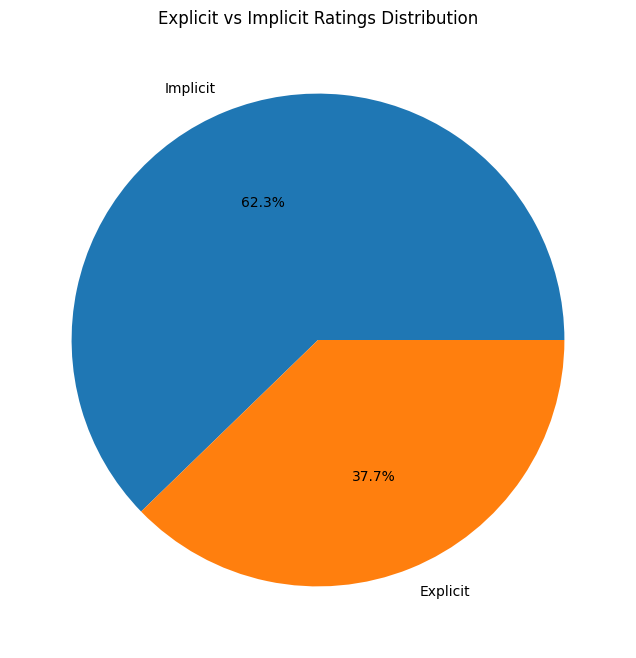

Type
Implicit    15564
Explicit     9436
Name: count, dtype: int64

In [7]:
# Explicit vs Implicit Ratings Analysis
ratings['Type'] = ratings['Book-Rating'].apply(
lambda x: 'Implicit' if x==0 else 'Explicit'
)
plt.figure(figsize=(8,8))
plt.pie(
    ratings['Type'].value_counts(),
    labels=ratings['Type'].value_counts().index,
    autopct='%1.1f%%'
)
plt.title("Explicit vs Implicit Ratings Distribution")
plt.show()
ratings['Type'].value_counts()


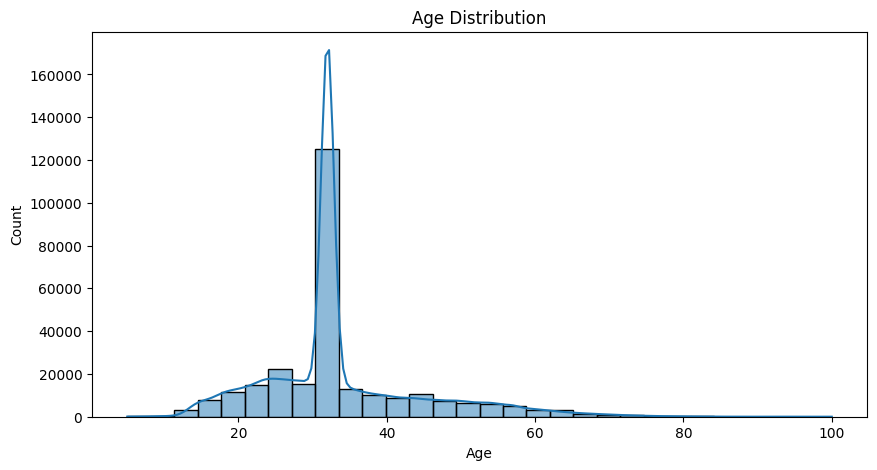

In [8]:
# User Age Distribution
plt.figure(figsize=(10,5))
sns.histplot(
users['Age'],
bins=30,
kde=True
)
plt.title("Age Distribution")
plt.show()

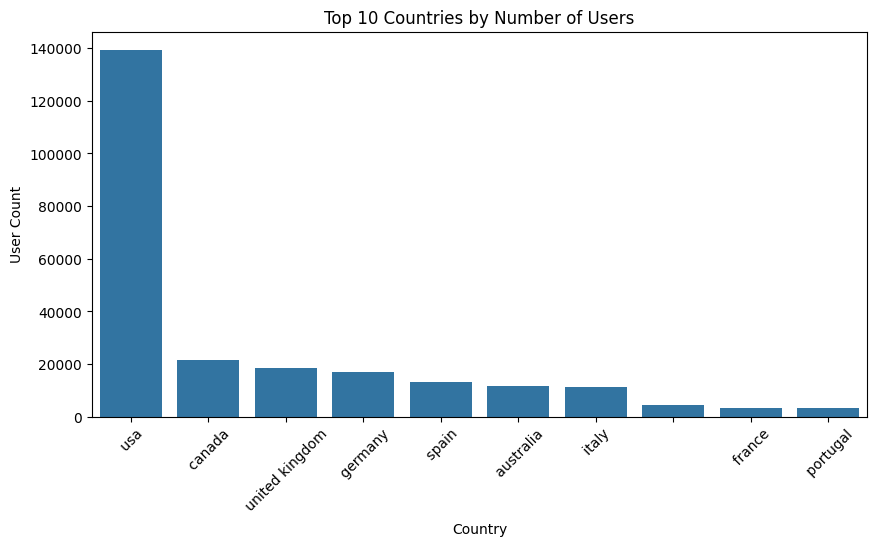

In [9]:
# Country-wise User Distribution
users['Country'] = users['Location'].str.split(',').str[-1]
top_country = users['Country'].value_counts().head(10)
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_country.index,
    y=top_country.values
)
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Number of Users")
plt.xlabel("Country")
plt.ylabel("User Count")
plt.show()

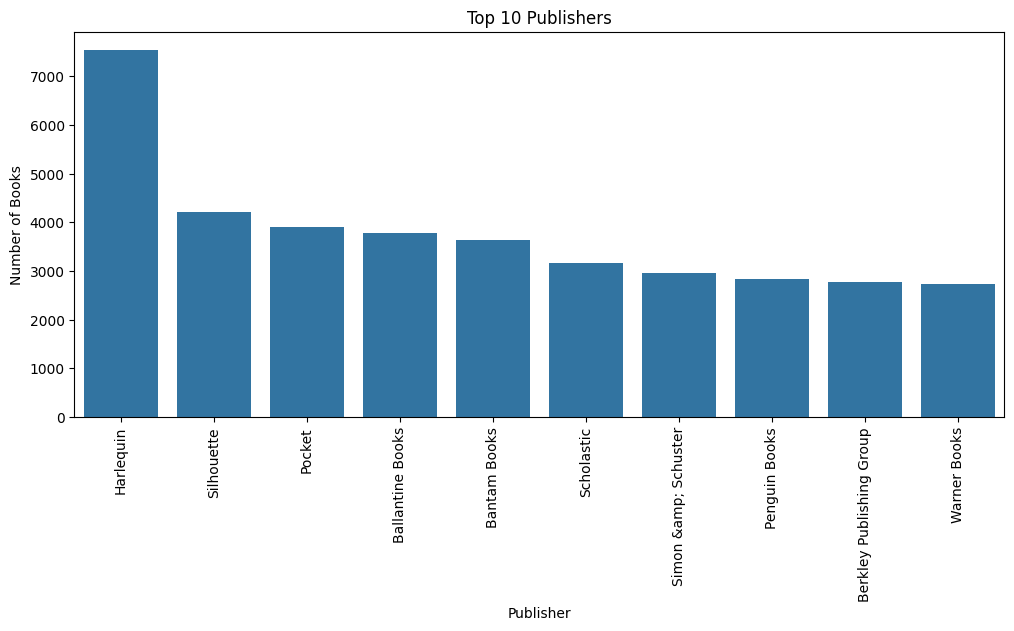

In [10]:
# Publisher Analysis
books['Publisher'].value_counts().head(20)
top_publishers = books[
    'Publisher'
].value_counts().head(10)
plt.figure(figsize=(12,5))
sns.barplot(
    x=top_publishers.index,
    y=top_publishers.values
)
plt.xticks(rotation=90)
plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Books")
plt.show()

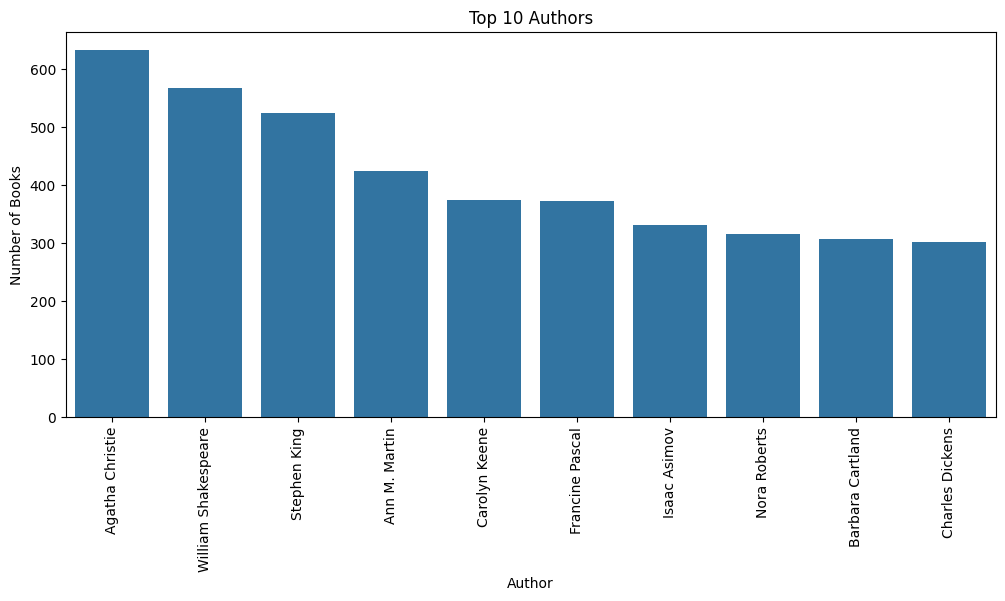

In [11]:
# Author Analysis
books['Book-Author'].value_counts().head(20)
top_authors = books[
    'Book-Author'
].value_counts().head(10)
plt.figure(figsize=(12,5))
sns.barplot(
    x=top_authors.index,
    y=top_authors.values
)
plt.xticks(rotation=90)
plt.title("Top 10 Authors")
plt.xlabel("Author")
plt.ylabel("Number of Books")
plt.show()

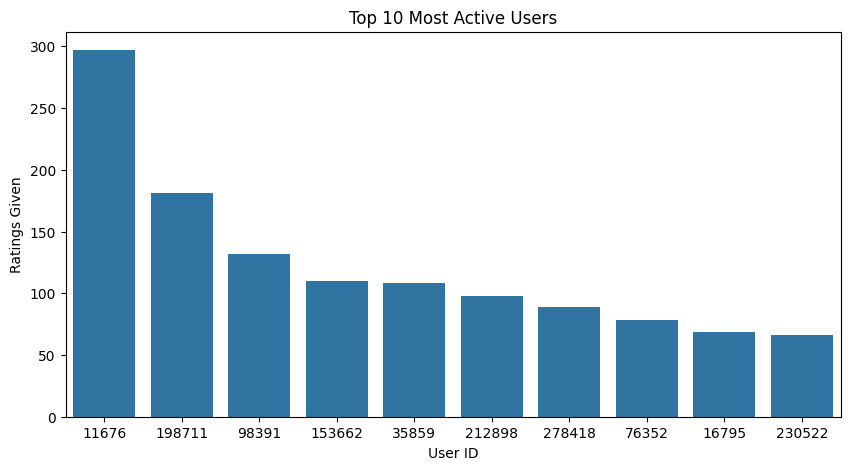

In [12]:
# Most Active Users Analysis
ratings['User-ID'].value_counts().head(20)
active_users = ratings[
    'User-ID'
].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(
    x=active_users.index.astype(str),
    y=active_users.values
)
plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Ratings Given")
plt.show()

#### STEP 6: FEATURE ENGINEERING

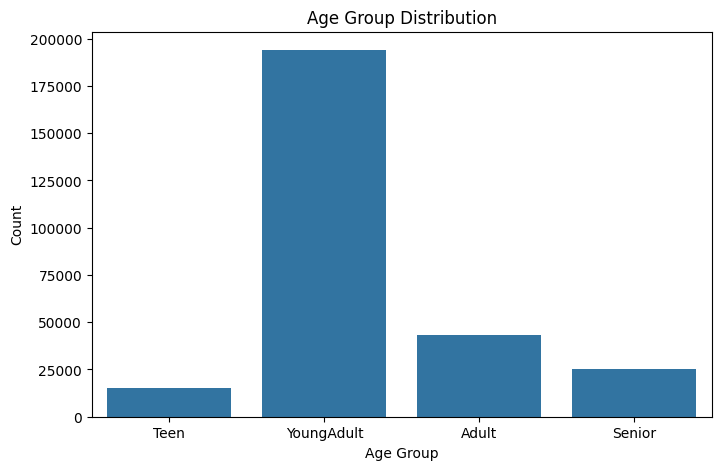

In [13]:
# User Features

# Age Group Feature
users['Age_Group'] = pd.cut(
users['Age'],
bins=[0,18,35,50,100],
labels=['Teen','YoungAdult','Adult','Senior']
)

# User Activity Feature
activity = ratings.groupby(
'User-ID'
).size()
users['Activity'] = users['User-ID'].map(activity)
# Age Group Distribution
plt.figure(figsize=(8,5))
sns.countplot(
    x='Age_Group',
    data=users
)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

C:\Users\SATYA GOWRI\AppData\Local\Temp\ipykernel_62088\69957133.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  books['Year-Of-Publication'].fillna(


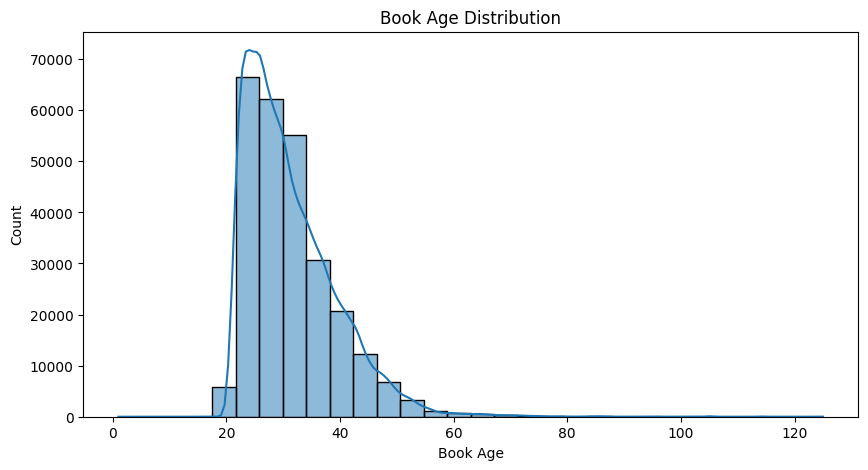

In [14]:
# Book Features

# Author Popularity Feature
author_popularity = books[
'Book-Author'
].value_counts()
books['Author_Popularity'] = books[
'Book-Author'
].map(author_popularity)


# Publisher Popularity Feature
publisher_popularity = books[
'Publisher'
].value_counts()

# Book Age Feature
books['Year-Of-Publication'].dtype
books['Year-Of-Publication'] = pd.to_numeric(
books['Year-Of-Publication'],
errors='coerce'
)
books['Year-Of-Publication'].isnull().sum()
books['Year-Of-Publication'].fillna(
books['Year-Of-Publication'].median(),
inplace=True
)
books = books[
(books['Year-Of-Publication'] >= 1900) &
(books['Year-Of-Publication'] <= 2025)
]
books['Book_Age'] = (
2025 -
books['Year-Of-Publication']
)

# Book Age Distribution
plt.figure(figsize=(10,5))
sns.histplot(
    books['Book_Age'],
    bins=30,
    kde=True
)
plt.title("Book Age Distribution")
plt.xlabel("Book Age")
plt.ylabel("Count")
plt.show()

# Title Length Feature
books['Title_Length'] = books[
'Book-Title'
].str.len()

# Rating-Based Features
avg_rating = ratings.groupby(
'ISBN'
)['Book-Rating'].mean()
rating_count = ratings.groupby(
'ISBN'
)['Book-Rating'].count()


Feature Correlation Heatmap

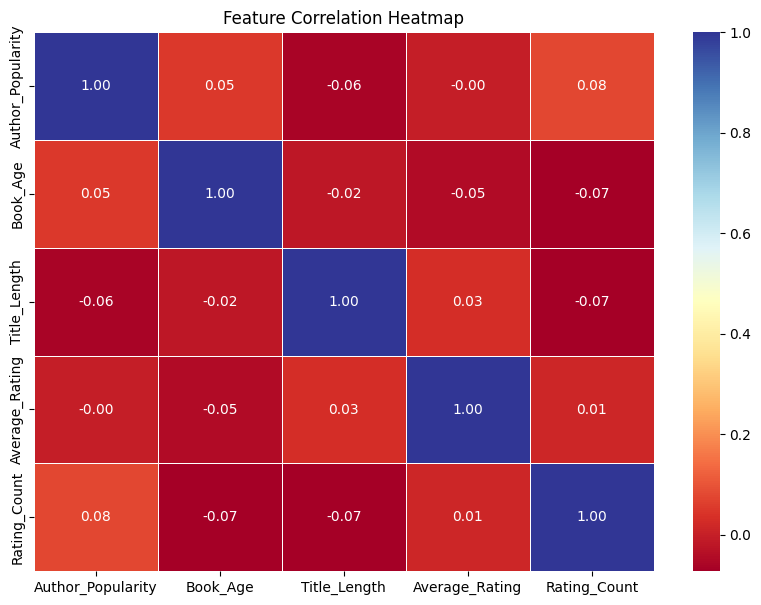

In [15]:
# Add rating features to books dataset
books['Average_Rating'] = books['ISBN'].map(avg_rating)
books['Rating_Count'] = books['ISBN'].map(rating_count)

# Select numerical features
heatmap_df = books[
    [
        'Author_Popularity',
        'Book_Age',
        'Title_Length',
        'Average_Rating',
        'Rating_Count'
    ]
]

# Remove missing values
heatmap_df = heatmap_df.dropna()

# Plot Heatmap
plt.figure(figsize=(10,7))
sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap='RdYlBu',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

 #### STEP 7: DATA INTEGRATION

In [16]:
book_rating = ratings.merge(
books,
on='ISBN'
)
final_df = book_rating.merge(
users,
on='User-ID'
)


 #### STEP 8: DATA PREPARATION

In [17]:
# Explicit Ratings Dataset
explicit_ratings = ratings[
ratings['Book-Rating'] > 0
]

!pip install scikit-surprise
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
explicit_ratings = ratings[
ratings['Book-Rating'] > 0
]
explicit_ratings.shape

# Creating Surprise Dataset
reader = Reader(rating_scale=(1,10))
data = Dataset.load_from_df(
explicit_ratings[
['User-ID','ISBN','Book-Rating']
],
reader
)

# Train-Test Split
trainset, testset = train_test_split(
data,
test_size=0.2,
random_state=42
)


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### STEP 9: MODEL BUILDING

#### 1. Popularity-Based Recommendation System
This model recommends the most popular books to all users based on the number of ratings and average ratings received by each book.

In [18]:
# Model 1 : Popularity-Based Recommendation System
popular_books = final_df.groupby(
    'Book-Title'
).agg({
    'Book-Rating':['mean','count']
})
popular_books.columns = [
    'Average_Rating',
    'Rating_Count'
]
top_books = popular_books.sort_values(
    by='Rating_Count',
    ascending=False
).head(10)
print(top_books)

                                                   Average_Rating  \
Book-Title                                                          
Wild Animus                                              0.805970   
The Lovely Bones: A Novel                                4.000000   
The Secret Life of Bees                                  3.692308   
A Painted House                                          2.600000   
House of Sand and Fog                                    2.684211   
Dreamcatcher                                             3.055556   
The Street Lawyer                                        3.111111   
The Da Vinci Code                                        5.444444   
She's Come Undone (Oprah's Book Club (Paperback))        2.882353   
Divine Secrets of the Ya-Ya Sisterhood: A Novel          3.470588   

                                                   Rating_Count  
Book-Title                                                       
Wild Animus                            

#### 2. Content-Based Recommendation System
This model recommends books similar to a selected book using book features such as title, author, and publisher.

In [19]:
# Model 2 : Content-Based Recommendation System
from sklearn.feature_extraction.text import TfidfVectorizer

# Fill Missing Values
books['Book-Title'] = books['Book-Title'].fillna('')
books['Book-Author'] = books['Book-Author'].fillna('')
books['Publisher'] = books['Publisher'].fillna('')

# Combine Features
books['Features'] = (
    books['Book-Title'].astype(str) + " " +
    books['Book-Author'].astype(str) + " " +
    books['Publisher'].astype(str)
)

# Filter Popular Books (Reduced Threshold)
book_rating_count = ratings.groupby(
    'ISBN'
)['Book-Rating'].count()

popular_books = book_rating_count[
    book_rating_count >= 5
].index

# Reduce dataset size 
books_filtered = books[
    books['ISBN'].isin(popular_books)
].copy().head(2000)

print("Books Used:", books_filtered.shape)

# Check before TF-IDF
if books_filtered.shape[0] < 2:
    print("Not enough books for Content-Based Filtering")
else:

    tfidf = TfidfVectorizer(
        stop_words='english',
        max_features=2000,
        min_df=1
    )

    tfidf_matrix = tfidf.fit_transform(
        books_filtered['Features']
    )

    print(
        "TF-IDF Matrix Shape:",
        tfidf_matrix.shape
    )

Books Used: (269, 14)
TF-IDF Matrix Shape: (269, 906)


#### 3. Collaborative Filtering (SVD)
SVD identifies hidden relationships between users and books by decomposing the user-item rating matrix into latent factors. 

In [20]:
# Model 3 : Collaborative Filtering (SVD)
svd = SVD(
    n_factors=50,
    n_epochs=10,
    lr_all=0.005,
    reg_all=0.02
)
# Model Training
svd.fit(trainset)
# SVD Predictions
svd_predictions = svd.test(testset)


#### 4. K-Nearest Neighbors (KNN)
KNN recommends books by finding users with similar preferences or books with similar rating patterns.

In [21]:
# Model 4 : KNN Recommendation System
from surprise import KNNBasic
knn_model = KNNBasic(
    k=20
)
knn_model.fit(trainset)
knn_predictions = knn_model.test(testset)
from surprise import accuracy
knn_rmse = accuracy.rmse(
    knn_predictions,
    verbose=False
)
print("KNN RMSE:", knn_rmse)

Computing the msd similarity matrix...
Done computing similarity matrix.
KNN RMSE: 1.9119823995423255


#### 5. Non-Negative Matrix Factorization (NMF)
NMF decomposes the user-item matrix into non-negative latent factors to predict ratings.

In [22]:
# Model 5 : Non-Negative Matrix Factorization (NMF)
from surprise import NMF
nmf_model = NMF(
    n_factors=20,
    n_epochs=20
)
nmf_model.fit(trainset)
nmf_predictions = nmf_model.test(testset)
nmf_rmse = accuracy.rmse(
    nmf_predictions,
    verbose=False
)
print("NMF RMSE:", nmf_rmse)

NMF RMSE: 2.08804498143967


#### 6. Baseline Recommendation System
Baseline predicts ratings using the global average rating along with user and book biases.

In [23]:
# Model 6 : Baseline Recommendation System
from surprise import BaselineOnly
baseline_model = BaselineOnly()
baseline_model.fit(trainset)
baseline_predictions = baseline_model.test(testset)
baseline_rmse = accuracy.rmse(
    baseline_predictions,
    verbose=False
)
print("Baseline RMSE:", baseline_rmse)

Estimating biases using als...
Baseline RMSE: 1.8624006398493762


#### 7: Neural Collaborative Filtering (NCF)
NCF is a deep learning-based recommendation model that learns complex interactions between users and books using neural networks.

In [24]:
# Data Preparation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Encode User IDs
user_ids = ratings['User-ID'].unique()
user_to_idx = {x:i for i,x in enumerate(user_ids)}
ratings['user_idx'] = ratings['User-ID'].map(user_to_idx)

# Encode ISBNs
book_ids = ratings['ISBN'].unique()
book_to_idx = {x:i for i,x in enumerate(book_ids)}
ratings['book_idx'] = ratings['ISBN'].map(book_to_idx)

X = ratings[['user_idx', 'book_idx']]
y = ratings['Book-Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n_users = len(user_ids)
n_books = len(book_ids)

In [25]:
# Build NCF Model
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten
from tensorflow.keras.layers import Dense, Concatenate
from tensorflow.keras.models import Model

user_input = Input(shape=(1,))
book_input = Input(shape=(1,))

user_embedding = Embedding(
    input_dim=n_users,
    output_dim=50
)(user_input)

book_embedding = Embedding(
    input_dim=n_books,
    output_dim=50
)(book_input)

user_vec = Flatten()(user_embedding)
book_vec = Flatten()(book_embedding)

concat = Concatenate()([user_vec, book_vec])

dense1 = Dense(128, activation='relu')(concat)
dense2 = Dense(64, activation='relu')(dense1)
dense3 = Dense(32, activation='relu')(dense2)

output = Dense(1)(dense3)

model = Model(
    inputs=[user_input, book_input],
    outputs=output
)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 1, 50)             │         512,700 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 1, 50)             │       1,001,600 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 50)                │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 50)                │               0 │ embedding_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 100)               │               0 │ flatten[0][0],             │
│                               │                           │                 │ flatten_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │          12,928 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │              33 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,537,597 (5.87 MB)

 Trainable params: 1,537,597 (5.87 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Train Model
history = model.fit(
    [X_train['user_idx'], X_train['book_idx']],
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=256
)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 19.8830 - mae: 2.9952 - val_loss: 13.6408 - val_mae: 3.2855
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 9.2406 - mae: 2.5429 - val_loss: 14.7113 - val_mae: 3.0903
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.9527 - mae: 1.0702 - val_loss: 15.4775 - val_mae: 3.1249
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.3786 - mae: 0.6192 - val_loss: 15.9979 - val_mae: 3.0894
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.8569 - mae: 0.4333 - val_loss: 16.7009 - val_mae: 3.1203
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.5934 - mae: 0.3438 - val_loss: 16.9578 - val_mae: 3.0786
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.4891 - mae: 0.2914 - val_loss: 17.5871 - val_mae: 3.1428
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.3875 - mae: 0.2485 - val_loss: 17.4117 - val_mae: 3.1268
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - lo

In [27]:
# Evaluate
loss, mae = model.evaluate(
    [X_test['user_idx'], X_test['book_idx']],
    y_test
)
ncf_mae = mae

print("MAE:", mae)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.5686 - mae: 3.0812
MAE: 3.1211531162261963


In [28]:
# NCF RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(
    [X_test['user_idx'], X_test['book_idx']]
)

ncf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("NCF RMSE:", ncf_rmse)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
NCF RMSE: 4.251214919625528


#### 8. DeepFM Model
DeepFM is a hybrid recommendation model that combines Factorization Machines and Deep Neural Networks to learn both low-order and high-order feature interactions for personalized recommendations.

In [29]:
# Data Preparation
from sklearn.preprocessing import LabelEncoder

deepfm_df = ratings.copy()

user_encoder = LabelEncoder()
book_encoder = LabelEncoder()

deepfm_df['user'] = user_encoder.fit_transform(
    deepfm_df['User-ID']
)

deepfm_df['book'] = book_encoder.fit_transform(
    deepfm_df['ISBN']
)

deepfm_df['rating'] = deepfm_df['Book-Rating']

num_users = deepfm_df['user'].nunique()
num_books = deepfm_df['book'].nunique()

from sklearn.model_selection import train_test_split

X = deepfm_df[['user','book']]
y = deepfm_df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

embedding_dim = 32

user_input = Input(shape=(1,))
book_input = Input(shape=(1,))

user_emb = Embedding(
    num_users,
    embedding_dim
)(user_input)

book_emb = Embedding(
    num_books,
    embedding_dim
)(book_input)

user_vec = Flatten()(user_emb)
book_vec = Flatten()(book_emb)

# FM Component
fm_part = Multiply()([
    user_vec,
    book_vec
])

# Deep Component
deep_part = Concatenate()([
    user_vec,
    book_vec
])

deep_part = Dense(
    128,
    activation='relu'
)(deep_part)

deep_part = Dense(
    64,
    activation='relu'
)(deep_part)

deep_part = Dense(
    32,
    activation='relu'
)(deep_part)

# Combine
combined = Concatenate()([
    fm_part,
    deep_part
])

output = Dense(1)(combined)

deepfm_model = Model(
    inputs=[user_input, book_input],
    outputs=output
)

deepfm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

deepfm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_3 (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_2 (Embedding)       │ (None, 1, 32)             │         328,128 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_3 (Embedding)       │ (None, 1, 32)             │         641,024 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_2 (Flatten)           │ (None, 32)                │               0 │ embedding_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_3 (Flatten)           │ (None, 32)                │               0 │ embedding_3[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 64)                │               0 │ flatten_2[0][0],           │
│                               │                           │                 │ flatten_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 128)               │           8,320 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 64)                │           8,256 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 32)                │               0 │ flatten_2[0][0],           │
│                               │                           │                 │ flatten_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 32)                │           2,080 │ dense_5[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_2 (Concatenate)   │ (None, 64)                │               0 │ multiply[0][0],            │
│                               │                           │                 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 1)                 │              65 │ concatenate_2[0][0]        │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 987,873 (3.77 MB)

 Trainable params: 987,873 (3.77 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Train DeepFM
deepfm_model.fit(
    [X_train['user'], X_train['book']],
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 20.5154 - mae: 3.0313 - val_loss: 13.7824 - val_mae: 3.2897
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 10.1899 - mae: 2.7081 - val_loss: 14.4989 - val_mae: 3.0658
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.3710 - mae: 1.1607 - val_loss: 15.4198 - val_mae: 3.1254
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4845 - mae: 0.6231 - val_loss: 16.2975 - val_mae: 3.1534
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9357 - mae: 0.4525 - val_loss: 16.7046 - val_mae: 3.1308
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6541 - mae: 0.3554 - val_loss: 17.1155 - val_mae: 3.1485
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5247 - mae: 0.3159 - val_loss: 17.4592 - val_mae: 3.1556
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4412 - mae: 0.2802 - val_loss: 17.5880 - val_mae: 3.1640
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - l

In [32]:
# Evaluate DeepFM
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

deepfm_pred = deepfm_model.predict(
    [X_test['user'], X_test['book']]
)

deepfm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        deepfm_pred
    )
)

deepfm_mae = mean_absolute_error(
    y_test,
    deepfm_pred
)

print("DeepFM RMSE:", deepfm_rmse)
print("DeepFM MAE:", deepfm_mae)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
DeepFM RMSE: 4.257780470421386
DeepFM MAE: 3.110177516937256


#### 9. Wide & Deep Model
Wide & Deep is a recommendation model that combines a wide component for memorization and a deep neural network for generalization. It helps recommend items based on both known and hidden user preferences.

In [33]:
from tensorflow.keras.layers import (
    Input, Embedding, Flatten,
    Dense, Dropout, Concatenate
)
from tensorflow.keras.models import Model

embedding_dim = 32

# Inputs
user_input = Input(shape=(1,), name='user_input')
book_input = Input(shape=(1,), name='book_input')

# Embeddings
user_embedding = Embedding(
    input_dim=num_users,
    output_dim=embedding_dim,
    name='user_embedding'
)(user_input)

book_embedding = Embedding(
    input_dim=num_books,
    output_dim=embedding_dim,
    name='book_embedding'
)(book_input)

# Flatten
user_vec = Flatten()(user_embedding)
book_vec = Flatten()(book_embedding)

# Wide Part
wide_part = Concatenate()([
    user_vec,
    book_vec
])

# Deep Part
deep_part = Dense(
    128,
    activation='relu'
)(wide_part)

deep_part = Dropout(0.3)(deep_part)

deep_part = Dense(
    64,
    activation='relu'
)(deep_part)

deep_part = Dropout(0.3)(deep_part)

deep_part = Dense(
    32,
    activation='relu'
)(deep_part)

# Combine Wide + Deep
combined = Concatenate()([
    wide_part,
    deep_part
])

# Output Layer
output = Dense(
    1,
    activation='linear'
)(combined)

# Model
wide_deep_model = Model(
    inputs=[user_input, book_input],
    outputs=output
)

wide_deep_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

wide_deep_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ book_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_embedding (Embedding)    │ (None, 1, 32)             │         328,128 │ user_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ book_embedding (Embedding)    │ (None, 1, 32)             │         641,024 │ book_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_4 (Flatten)           │ (None, 32)                │               0 │ user_embedding[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_5 (Flatten)           │ (None, 32)                │               0 │ book_embedding[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_3 (Concatenate)   │ (None, 64)                │               0 │ flatten_4[0][0],           │
│                               │                           │                 │ flatten_5[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 128)               │           8,320 │ concatenate_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense_8[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 64)                │           8,256 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ dense_9[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_10 (Dense)              │ (None, 32)                │           2,080 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_4 (Concatenate)   │ (None, 96)                │               0 │ concatenate_3[0][0],       │
│                               │                           │                 │ dense_10[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_11 (Dense)              │ (None, 1)                 │              97 │ concatenate_4[0][0]        │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 987,905 (3.77 MB)

 Trainable params: 987,905 (3.77 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Training
history = wide_deep_model.fit(
    [X_train['user'], X_train['book']],
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=256,
    verbose=1
)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 20.4911 - mae: 2.9178 - val_loss: 13.8653 - val_mae: 3.3323
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 10.5183 - mae: 2.7461 - val_loss: 14.5990 - val_mae: 3.0913
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.6855 - mae: 1.2732 - val_loss: 15.2754 - val_mae: 3.1424
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0922 - mae: 0.8688 - val_loss: 15.6303 - val_mae: 3.1051
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6079 - mae: 0.7236 - val_loss: 16.0382 - val_mae: 3.1333
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.2711 - mae: 0.6289 - val_loss: 16.3259 - val_mae: 3.1314
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1069 - mae: 0.5697 - val_loss: 16.6709 - val_mae: 3.1398
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9703 - mae: 0.5259 - val_loss: 16.6712 - val_mae: 3.1324
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - l

In [35]:
# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

wide_pred = wide_deep_model.predict(
    [X_test['user'], X_test['book']]
)

wide_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        wide_pred
    )
)

wide_mae = mean_absolute_error(
    y_test,
    wide_pred
)

print("Wide & Deep RMSE:", wide_rmse)
print("Wide & Deep MAE:", wide_mae)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Wide & Deep RMSE: 4.143013894822274
Wide & Deep MAE: 3.1116292476654053


#### STEP 10: MODEL EVALUATION

In [37]:
from surprise import accuracy

# SVD
svd_rmse = accuracy.rmse(svd_predictions, verbose=False)
svd_mae = accuracy.mae(svd_predictions, verbose=False)

# KNN
knn_rmse = accuracy.rmse(knn_predictions, verbose=False)
knn_mae = accuracy.mae(knn_predictions, verbose=False)

# NMF
nmf_rmse = accuracy.rmse(nmf_predictions, verbose=False)
nmf_mae = accuracy.mae(nmf_predictions, verbose=False)

# Baseline
baseline_rmse = accuracy.rmse(baseline_predictions, verbose=False)
baseline_mae = accuracy.mae(baseline_predictions, verbose=False)

# Print Results
print("SVD RMSE:", svd_rmse)
print("SVD MAE:", svd_mae)

print("KNN RMSE:", knn_rmse)
print("KNN MAE:", knn_mae)

print("NMF RMSE:", nmf_rmse)
print("NMF MAE:", nmf_mae)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

print("NCF RMSE:", ncf_rmse)
print("NCF MAE:", ncf_mae)

print("DeepFM RMSE:", deepfm_rmse)
print("DeepFM MAE:", deepfm_mae)

print("Wide & Deep RMSE:", wide_rmse)
print("Wide & Deep MAE:", wide_mae)

SVD RMSE: 1.8638783273334933
SVD MAE: 1.4777407967381007
KNN RMSE: 1.9119823995423255
KNN MAE: 1.5308811740454313
NMF RMSE: 2.08804498143967
NMF MAE: 1.66211353651111
Baseline RMSE: 1.8624006398493762
Baseline MAE: 1.4757793269344464
NCF RMSE: 4.251214919625528
NCF MAE: 3.1211531162261963
DeepFM RMSE: 4.257780470421386
DeepFM MAE: 3.110177516937256
Wide & Deep RMSE: 4.143013894822274
Wide & Deep MAE: 3.1116292476654053


#### STEP 11: MODEL COMPARISON

In [38]:
comparison = pd.DataFrame({
    'Model': [
        'KNN',
        'SVD',
        'NMF',
        'Baseline',
        'NCF',
        'DeepFM',
        'Wide & Deep'
    ],
    'RMSE': [
        knn_rmse,
        svd_rmse,
        nmf_rmse,
        baseline_rmse,
        ncf_rmse,
        deepfm_rmse,
        wide_rmse
    ],
    'MAE': [
        knn_mae,
        svd_mae,
        nmf_mae,
        baseline_mae,
        ncf_mae,
        deepfm_mae,
        wide_mae
    ]
})

comparison = comparison.sort_values(
    by='RMSE',
    ascending=True
).reset_index(drop=True)

comparison.index += 1

comparison

,Model,RMSE,MAE
1,Baseline,1.862401,1.475779
2,SVD,1.863878,1.477741
3,KNN,1.911982,1.530881
4,NMF,2.088045,1.662114
5,Wide & Deep,4.143014,3.111629
6,NCF,4.251215,3.121153
7,DeepFM,4.257780,3.110178


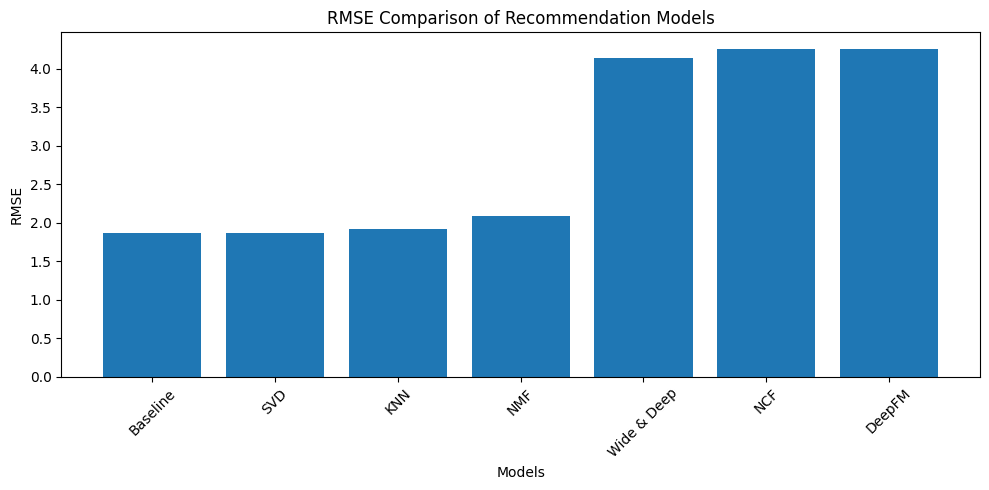

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    comparison['Model'],
    comparison['RMSE']
)

plt.title('RMSE Comparison of Recommendation Models')
plt.xlabel('Models')
plt.ylabel('RMSE')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

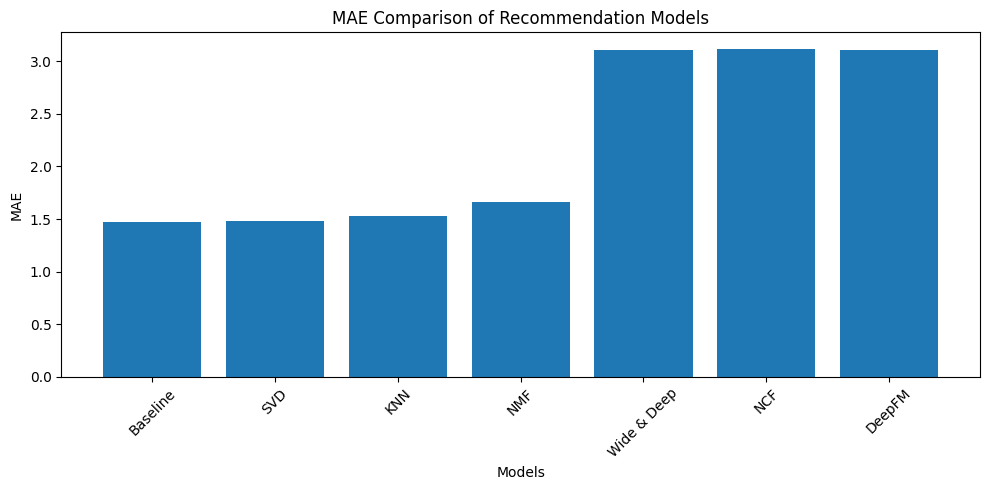

In [40]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison['Model'],
    comparison['MAE']
)

plt.title('MAE Comparison of Recommendation Models')
plt.xlabel('Models')
plt.ylabel('MAE')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### STEP 12: VISUALIZATION

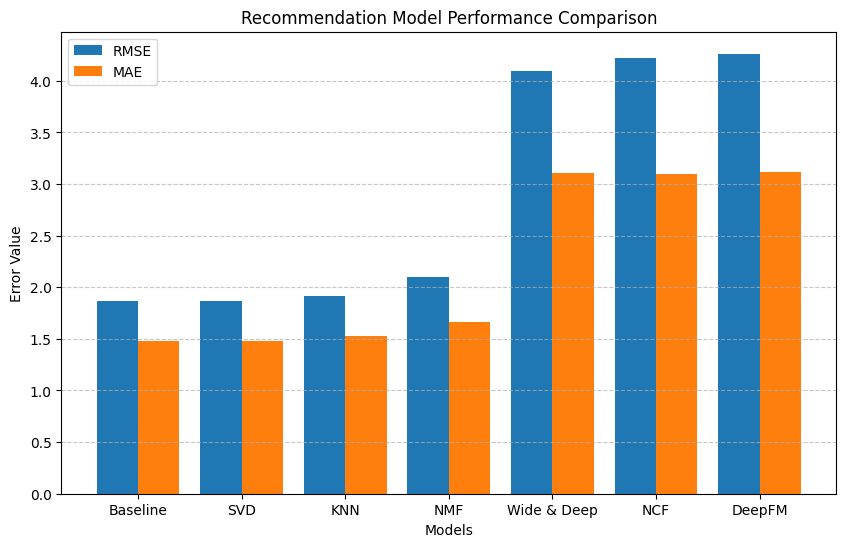

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": ["Baseline", "SVD", "KNN", "NMF", "NCF","DeepFM","Wide & Deep"],
    "RMSE": [1.862401, 1.864984, 1.911982, 2.094517, 4.217386, 4.262207, 4.098940],
    "MAE": [1.475779, 1.478620, 1.530881, 1.666700, 3.099663, 3.112426, 3.106866]
})

comparison = comparison.sort_values("RMSE")

plt.figure(figsize=(10,6))

x = range(len(comparison))

plt.bar(
    [i-0.2 for i in x],
    comparison["RMSE"],
    width=0.4,
    label="RMSE"
)

plt.bar(
    [i+0.2 for i in x],
    comparison["MAE"],
    width=0.4,
    label="MAE"
)

plt.xticks(x, comparison["Model"])
plt.ylabel("Error Value")
plt.xlabel("Models")
plt.title("Recommendation Model Performance Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [42]:
# Remove models that are not directly comparable
comparable_models = comparison[
    comparison['Model'].isin([
        'SVD',
        'KNN',
        'NMF',
        'Baseline',
        'NCF',
        'DeepFM',
        'Wide & Deep'
    ])
]

# Best Overall Model
best_model = comparable_models.loc[
    comparable_models['RMSE'].idxmin()
]

print("Best Overall Recommendation Model")
print("--------------------------------")
print("Model :", best_model['Model'])
print("RMSE  :", round(best_model['RMSE'], 4))
print("MAE   :", round(best_model['MAE'], 4))

Best Overall Recommendation Model
--------------------------------
Model : Baseline
RMSE  : 1.8624
MAE   : 1.4758


#### STEP 13: Hyperparameter Tuning

#### 1.SVD Hyperparameter Tuning

In [43]:
from surprise import SVD
from surprise.model_selection import GridSearchCV

param_grid = {
    'n_factors': [50, 100, 150],
    'n_epochs': [20, 30, 50],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.02, 0.05, 0.1]
}

gs_svd = GridSearchCV(
    SVD,
    param_grid,
    measures=['rmse', 'mae'],
    cv=3,
    n_jobs=-1
)

gs_svd.fit(data)

print("Best RMSE Score:", gs_svd.best_score['rmse'])
print("Best Parameters:", gs_svd.best_params['rmse'])

Best RMSE Score: 1.7960908496948795
Best Parameters: {'n_factors': 50, 'n_epochs': 50, 'lr_all': 0.005, 'reg_all': 0.05}


In [44]:
# Train Best SVD Model
best_svd = SVD(
    n_factors=gs_svd.best_params['rmse']['n_factors'],
    n_epochs=gs_svd.best_params['rmse']['n_epochs'],
    lr_all=gs_svd.best_params['rmse']['lr_all'],
    reg_all=gs_svd.best_params['rmse']['reg_all']
)

best_svd.fit(trainset)

svd_tuned_predictions = best_svd.test(testset)

from surprise import accuracy

svd_tuned_rmse = accuracy.rmse(
    svd_tuned_predictions,
    verbose=False
)

svd_tuned_mae = accuracy.mae(
    svd_tuned_predictions,
    verbose=False
)

print("Tuned SVD RMSE:", svd_tuned_rmse)
print("Tuned SVD MAE:", svd_tuned_mae)

Tuned SVD RMSE: 1.8421859615613259
Tuned SVD MAE: 1.4433226103333572


#### 2. Baseline Hyperparameter Tuning

In [45]:
from surprise import BaselineOnly
from surprise.model_selection import GridSearchCV

param_grid = {
    'bsl_options': {
        'method': ['als', 'sgd'],
        'n_epochs': [5, 10, 20],
        'reg_u': [10, 15, 20],
        'reg_i': [5, 10, 15]
    }
}

gs_baseline = GridSearchCV(
    BaselineOnly,
    param_grid,
    measures=['rmse', 'mae'],
    cv=3,
    n_jobs=-1
)

gs_baseline.fit(data)

print("Best RMSE Score:", gs_baseline.best_score['rmse'])
print("Best Parameters:", gs_baseline.best_params['rmse'])

Best RMSE Score: 1.7996495912957193
Best Parameters: {'bsl_options': {'method': 'sgd', 'n_epochs': 20, 'reg_u': 10, 'reg_i': 5}}


In [46]:
best_baseline = BaselineOnly(
    bsl_options=gs_baseline.best_params['rmse']['bsl_options']
)

best_baseline.fit(trainset)

baseline_tuned_predictions = best_baseline.test(testset)

baseline_tuned_rmse = accuracy.rmse(
    baseline_tuned_predictions,
    verbose=False
)

baseline_tuned_mae = accuracy.mae(
    baseline_tuned_predictions,
    verbose=False
)

print("Tuned Baseline RMSE:", baseline_tuned_rmse)
print("Tuned Baseline MAE:", baseline_tuned_mae)

Estimating biases using sgd...
Tuned Baseline RMSE: 1.847821894990739
Tuned Baseline MAE: 1.4563377804359843


In [54]:
# ==========================================
# Recommendation Function
# ==========================================

import pandas as pd

def recommend_books(user_id, model, books, ratings, top_n=10):

    # Books already rated by the user
    rated_books = ratings.loc[
        ratings["User-ID"] == user_id,
        "ISBN"
    ].unique()

    # Books not rated by the user
    candidate_books = books[
        ~books["ISBN"].isin(rated_books)
    ].copy()

    recommendations = []

    # Predict rating for every unseen book
    for isbn in candidate_books["ISBN"].unique():

        prediction = model.predict(user_id, isbn)

        recommendations.append(
            (isbn, prediction.est)
        )

    # Sort by predicted rating
    recommendations = sorted(
        recommendations,
        key=lambda x: x[1],
        reverse=True
    )

    # Top N Books
    top_books = recommendations[:top_n]

    recommendation_df = pd.DataFrame(
        top_books,
        columns=["ISBN", "Predicted Rating"]
    )

    # Merge with Book Details
    recommendation_df = recommendation_df.merge(
        books[
            [
                "ISBN",
                "Book-Title",
                "Book-Author",
                "Publisher",
                "Image-URL-L"
            ]
        ],
        on="ISBN",
        how="left"
    )

    return recommendation_df

In [55]:
# Test the Recommendation Function
recommend_books(
    user_id=276726,
    model=best_svd,
    books=books,
    ratings=ratings,
    top_n=10
)

,ISBN,Predicted Rating,Book-Title,Book-Author,Publisher,Image-URL-L
0,0385504209,8.750104,The Da Vinci Code,Dan Brown,Doubleday,http://images.amazon.com/images/P/0385504209.0...
1,0345339681,8.645540,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,Del Rey,http://images.amazon.com/images/P/0345339681.0...
2,0060915544,8.625589,The Bean Trees,Barbara Kingsolver,Perennial,http://images.amazon.com/images/P/0060915544.0...
3,0060916508,8.621290,Their Eyes Were Watching God: A Novel,Zora Neale Hurston,Perennial,http://images.amazon.com/images/P/0060916508.0...
4,0375706771,8.587668,Midwives: A Novel,Chris Bohjalian,Vintage,http://images.amazon.com/images/P/0375706771.0...
5,043935806X,8.491154,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,Scholastic,http://images.amazon.com/images/P/043935806X.0...
6,0553296981,8.482573,Anne Frank: The Diary of a Young Girl,ANNE FRANK,Bantam,http://images.amazon.com/images/P/0553296981.0...
7,0385492081,8.431494,Into Thin Air : A Personal Account of the Mt. ...,JON KRAKAUER,Anchor,http://images.amazon.com/images/P/0385492081.0...
8,0439064872,8.429814,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,Scholastic,http://images.amazon.com/images/P/0439064872.0...
9,0590353403,8.417027,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,Scholastic,http://images.amazon.com/images/P/0590353403.0...


#### Final Comparison Table Code

In [56]:
final_tuned_comparison = pd.DataFrame({
    'Model': [
        'Tuned SVD',
        'Tuned Baseline'
    ],
    'RMSE': [
        svd_tuned_rmse,
        baseline_tuned_rmse
    ],
    'MAE': [
        svd_tuned_mae,
        baseline_tuned_mae
    ]
})

final_tuned_comparison = final_tuned_comparison.sort_values(
    by='RMSE'
)

print(final_tuned_comparison)

            Model      RMSE       MAE
0       Tuned SVD  1.842186  1.443323
1  Tuned Baseline  1.847822  1.456338


##### Best Model for Book Recommendation

In [57]:
best_model = final_tuned_comparison.loc[
    final_tuned_comparison['RMSE'].idxmin()
]

print("🏆Final Best Performing Model")
print("----------------")
print("Model :", best_model['Model'])
print("📊RMSE  :", round(best_model['RMSE'], 4))
print("📊MAE   :", round(best_model['MAE'], 4))

🏆Final Best Performing Model
----------------
Model : Tuned SVD
📊RMSE  : 1.8422
📊MAE   : 1.4433


#### Save the Tuned SVD Model

In [58]:
# ==========================================
# Save Model and Required Files
# ==========================================

import pickle

pickle.dump(best_svd, open("best_svd_model.pkl","wb"))
pickle.dump(books, open("books.pkl","wb"))
pickle.dump(ratings, open("ratings.pkl","wb"))
pickle.dump(users, open("users.pkl","wb"))
pickle.dump(final_df, open("final_df.pkl","wb"))

print("Deployment files saved successfully!")

print("===================================")
print("All files saved successfully!")
print("===================================")

Deployment files saved successfully!
All files saved successfully!
